# Entrega 2 · Análisis exploratorio — ¿gana el underdog?

**Pregunta del proyecto.** ¿Ganará el equipo no favorito (*underdog*) un partido, dadas las probabilidades implícitas
pre-partido y métricas construidas a partir de sus jugadores titulares?

- **Una fila = un partido.** Clave: `match_id`.
- **Variable objetivo:** `gano_no_favorito` (True si ganó el underdog; empate o derrota = False).
- **Momento de la predicción:** con las alineaciones ya publicadas (~1 h antes) y antes del pitazo. Una columna solo puede
  ser feature si existe en ese momento.
- **De dónde sale el dataset:** es el Silver que construye el DAG `underdog_pipeline` en Airflow. El DAG consulta `source-db`
  (PostgreSQL), guarda Bronze y arma Silver. Este notebook solo lo lee.

## Qué cambió desde la Entrega 1

El pipeline ya no lanza scripts sobre el SQLite: Airflow consulta una base PostgreSQL por una Connection, guarda el resultado
crudo de cada consulta como Bronze y arma Silver sin goles ni resultados, que pasan a un dataset de auditoría. La pregunta no
cambió, pero el target sí: ya no tiene nulos, porque ahora solo entran los partidos con un underdog identificable
(|prob_home − prob_away| > 0,05).

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "include" / "config.py").exists())
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore", category=FutureWarning)

from include.config import AUDIT_DIR, INTERMEDIATE_DIR, SILVER_DATASET_PATH, TARGET_COLUMN, UNDERDOG_GAP_CANDIDATES, UNDERDOG_MIN_PROB_GAP
from include.src import columns as catalog
from include.src.profiling import label_stability, stability_by_gap_band, threshold_sensitivity
from include.src.quality_check import run_quality_checks, single_feature_auc
from include.src.semaforo import SEMAFORO, brecha_spearman_pearson, correlacion, eta_cuadrado, separacion_estandarizada, zona, zonas_de_candidatas
from include.src.transform import underdog_gap

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
BLUE, ORANGE, GRAY, INK = "#2a78d6", "#eb6834", "#8a8984", "#52514e"
ZONE_COLOR = {"rojo": "#f8e1dc", "amarillo": "#fbeed6", "verde": "#deeee4"}
EMOJI = {"rojo": "🔴", "amarillo": "🟡", "verde": "🟢"}
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRAY, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold", "legend.frameon": False,
})


def semaforo(medida: str, valor: float) -> str:
    z = zona(medida, valor)
    decimals = 4 if medida == "eta2" else 3
    return f"{valor:.{decimals}f} → {EMOJI[z]} {z}".replace(".", ",")


df = pd.read_parquet(SILVER_DATASET_PATH)
spec = {c.name: c for c in catalog.SILVER_COLUMNS}
print(f"Silver: {df.shape[0]:,} filas x {df.shape[1]} columnas".replace(",", "."))

Silver: 17.959 filas x 31 columnas


# Parte 1 — Perfil del dataset

## Lo que se verifica con un número
Los mismos comandos de la consigna, sobre `df`.

In [2]:
print("Tamaño — df.shape:", df.shape)
print("\nTipos — df.dtypes.value_counts():")
print(df.dtypes.value_counts().to_string())
print("\nNulos por columna — df.isna().mean().sort_values(ascending=False) (las que tienen alguno):")
nulos = df.isna().mean().sort_values(ascending=False)
print(nulos[nulos > 0].to_string())
print("\nColumnas sin información — df.columns[df.nunique() <= 1]:", list(df.columns[df.nunique() <= 1]))
print("Duplicados de la clave — df['match_id'].duplicated().sum():", df["match_id"].duplicated().sum())
print("\nDistribución del objetivo — df['gano_no_favorito'].value_counts(normalize=True):")
print(df["gano_no_favorito"].value_counts(normalize=True).to_string())
print("\nAsimetría de las numéricas — df.select_dtypes('number').skew().sort_values():")
print(df.select_dtypes("number").skew().sort_values().round(3).to_string())

Tamaño — df.shape: (17959, 31)

Tipos — df.dtypes.value_counts():
float64           21
str                6
int64              2
datetime64[ns]     1
bool               1

Nulos por columna — df.isna().mean().sort_values(ascending=False) (las que tienen alguno):
nofav_gk_overall_gap     0.000223
fav_formacion            0.000111
nofav_att_overall_gap    0.000111
nofav_mid_overall_gap    0.000111
nofav_formacion          0.000111
nofav_def_overall_gap    0.000111

Columnas sin información — df.columns[df.nunique() <= 1]: []
Duplicados de la clave — df['match_id'].duplicated().sum(): 0

Distribución del objetivo — df['gano_no_favorito'].value_counts(normalize=True):
gano_no_favorito
False    0.796537
True     0.203463

Asimetría de las numéricas — df.select_dtypes('number').skew().sort_values():
prob_draw                        -1.305
prob_no_favorito                 -0.339
nofav_xi_overall_mean_gap        -0.235
nofav_top3_overall_gap           -0.193
nofav_att_overall_gap            -0

**Qué hay que saber decir**

| Qué | Respuesta |
|---|---|
| **Tamaño** | 17.959 filas × 31 columnas. Una fila es un partido. |
| **Tipos** | 21 decimales, 6 de texto, 2 enteros, 1 fecha y 1 booleano (el objetivo). Ninguna numérica quedó como texto: las 6 de texto son categóricas por naturaleza (`temporada` "2012/2013", `liga`, `odds_source`, `equipo_favorito` y las dos formaciones "4-4-2"). |
| **Nulos** | Las tres peores son `nofav_gk_overall_gap` (4 filas, 0,022%), `fav_formacion` y `nofav_att_overall_gap` (2 filas cada una, 0,011%). Todos son **faltantes de verdad**: en 4 partidos la fuente trae las coordenadas Y de la alineación vacías o en 0, y no se puede ubicar al arquero, la línea o la formación. **Nulos estructurales en Silver: ninguno.** En la Entrega 1 el target tenía 103 nulos estructurales (partidos con probabilidades idénticas, donde no existe underdog): ahora esas filas se sacan. |
| **Constantes** | Ninguna. `es_partido_parejo` habría quedado constante después del filtro, y por eso ya no está. |
| **Duplicados de la clave** | 0. |
| **Objetivo** | 20,35% True / 79,65% False. Ninguna clase se come todo, pero 4 de cada 5 partidos son negativos: decir siempre "no gana" ya da 79,65% de *accuracy*. En la Entrega 3 se evalúa con AUC y log-loss y se corta en el tiempo respetando la proporción. |
| **Asimetría** | Solo `prob_draw` tiene cola larga (−1,3): empates improbables en partidos desparejos. Su relación con el objetivo es recta (brecha Spearman − Pearson 0,013), así que no se transforma. El skew de `match_id` no significa nada, porque es la clave. |

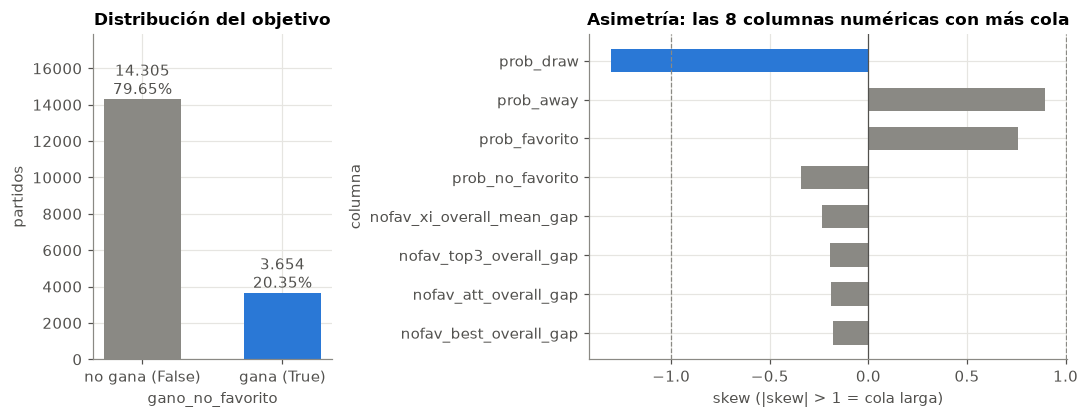

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.9), gridspec_kw={"width_ratios": [1, 2]})
counts = df[TARGET_COLUMN].value_counts().reindex([False, True])
bars = ax1.bar(["no gana (False)", "gana (True)"], counts.values, color=[GRAY, BLUE], width=0.55)
for bar, n in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, n, f"{n:,}\n{n / len(df):.2%}".replace(",", "."), ha="center", va="bottom", color=INK)
ax1.set_ylim(0, counts.max() * 1.25)
ax1.set_title("Distribución del objetivo")
ax1.set_xlabel("gano_no_favorito")
ax1.set_ylabel("partidos")

skew = df.select_dtypes("number").drop(columns="match_id").skew()
top = skew.reindex(skew.abs().sort_values(ascending=False).index).head(8)[::-1]
ax2.barh(top.index, top.values, color=[BLUE if abs(v) > 1 else GRAY for v in top.values], height=0.6)
ax2.axvline(0, color=INK, linewidth=0.8)
for x in (-1, 1):
    ax2.axvline(x, color=GRAY, linestyle="--", linewidth=0.8)
ax2.set_title("Asimetría: las 8 columnas numéricas con más cola")
ax2.set_xlabel("skew (|skew| > 1 = cola larga)")
ax2.set_ylabel("columna")
plt.tight_layout()
plt.show()

### Qué filas quedaron afuera y por qué
Cada partido excluido queda registrado con su motivo en `include/data/audit/excluded_matches.parquet`.

In [4]:
excluded = pd.read_parquet(AUDIT_DIR / "excluded_matches.parquet")
order = ["liga_sin_cuotas", "alineacion_incompleta", "sin_cuotas_1x2", "cuota_empate_incoherente", "sin_underdog_identificable", "partido_parejo"]
funnel = excluded["motivo"].value_counts().reindex(order).rename("partidos excluidos").to_frame()
funnel["etapa del DAG"] = ["prepare_matches"] * 4 + ["filter_valid_underdogs"] * 2
total = len(excluded) + len(df)
print(f"Partidos en la fuente: {total:,} -> en Silver: {len(df):,} ({len(df) / total:.1%})".replace(",", "."))
funnel

Partidos en la fuente: 25.979 -> en Silver: 17.959 (69.1%)


,partidos excluidos,etapa del DAG
motivo,,
liga_sin_cuotas,3342,prepare_matches
alineacion_incompleta,2910,prepare_matches
sin_cuotas_1x2,33,prepare_matches
cuota_empate_incoherente,32,prepare_matches
sin_underdog_identificable,103,filter_valid_underdogs
partido_parejo,1600,filter_valid_underdogs


---
# Parte 2 — Cuatro fichas de hipótesis

Cada ficha tiene los seis campos del TP2 en su orden. El número de cada resultado se lee contra el **semáforo** de la cátedra,
aplicado sobre el valor absoluto:

| Medida | Cuándo se usa | Rojo | Amarillo | Verde |
|---|---|---|---|---|
| Separación estandarizada | una numérica entre dos grupos | < 0,2 | 0,2 a 0,8 | > 0,8 |
| η² (razón de correlación) | una numérica entre muchos grupos | < 0,05 | 0,05 a 0,25 | > 0,25 |
| Correlación | dos numéricas | < 0,2 | 0,2 a 0,6 | > 0,6 |
| Brecha Spearman − Pearson | detectar que la relación no es recta | < 0,05 | 0,05 a 0,15 | > 0,15 |

En verde o rojo la ficha termina. Solo el amarillo habilita un movimiento (partir la población, controlar una tercera variable
o cambiar la escala), y se elige por lo que muestra el gráfico. Máximo dos por ficha.

| Ficha | Pregunta | Plantilla | Resultado |
|---|---|---|---|
| H1 | responder: cómo se define el underdog | comparación, dos grupos | 🟢 confirmada |
| H2 | responder: qué hace ganar al underdog | comparación, dos grupos | 🟡 → movimiento → 🔴 refutada |
| H3 | decidir columnas: subatributos del arquero | asociación, dos numéricas | 🟢 confirmada |
| H4 | decidir columna: `liga` | comparación, muchos grupos | 🔴 refutada |

## H1 · Los partidos muy parejos no tienen un underdog estable
*Pregunta: responder (dominio). Plantilla: comparación de una numérica entre dos grupos.*

**1. La afirmación**
En los partidos donde Pinnacle y Bet365 eligen **distinto favorito**, `|prob_home − prob_away|` es menor que en los partidos
donde coinciden.

**2. Qué espero ver** **[BORRADOR — reescribir con sus palabras antes de entregar]**
En la Entrega 1 marcamos como "parejo" a todo partido con diferencia menor a 0,05, sin haberlo medido. Esperamos que las casas
discrepen solo cuando la diferencia es muy chica. No sabemos hasta dónde llega esa zona, ni si 0,05 es un corte demasiado alto
o demasiado bajo.

**3. Cómo la mido**
Plantilla de comparación → **separación estandarizada** de `|prob_home − prob_away|` entre el grupo "el favorito cambia según la
casa" y el grupo "el favorito es el mismo". Se usan los partidos donde cotizan las dos casas (desde 2012/13). Gráfico:
distribución de la diferencia en cada grupo.

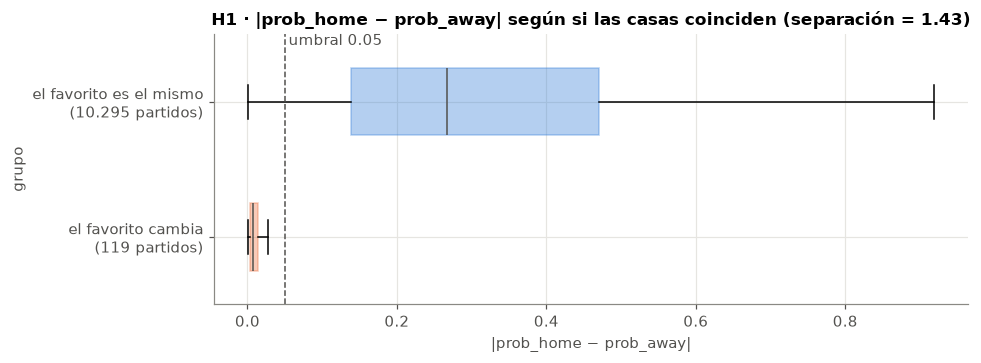

Separación estandarizada: 1,428 → 🟢 verde
Mediana de la diferencia: 0.0073 (cambia) vs 0.2675 (mismo favorito); máxima con discrepancia: 0.0416


In [5]:
candidates = pd.read_parquet(INTERMEDIATE_DIR / "matches_with_target.parquet")
candidates = candidates[candidates["equipo_favorito"].notna()].copy()
stability = label_stability(candidates)
both = stability["favorito_cambia_ps_b365"].notna()
h1 = pd.DataFrame({"gap": underdog_gap(candidates)[both], "estable": ~stability.loc[both, "favorito_cambia_ps_b365"].astype(bool)})
d_h1 = separacion_estandarizada(h1["gap"], h1["estable"])

fig, ax = plt.subplots(figsize=(9, 3.4))
groups = [h1.loc[~h1["estable"], "gap"], h1.loc[h1["estable"], "gap"]]
labels = [f"el favorito cambia\n({len(groups[0]):,} partidos)".replace(",", "."), f"el favorito es el mismo\n({len(groups[1]):,} partidos)".replace(",", ".")]
bp = ax.boxplot(groups, orientation="horizontal", tick_labels=labels, widths=0.5, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], [ORANGE, BLUE]):
    patch.set_facecolor(color); patch.set_alpha(0.35); patch.set_edgecolor(color)
for med in bp["medians"]:
    med.set_color(INK)
ax.axvline(UNDERDOG_MIN_PROB_GAP, color=INK, linestyle="--", linewidth=1)
ax.text(UNDERDOG_MIN_PROB_GAP + 0.005, 2.42, f"umbral {UNDERDOG_MIN_PROB_GAP}", color=INK)
ax.set_title(f"H1 · |prob_home − prob_away| según si las casas coinciden (separación = {d_h1:.2f})")
ax.set_xlabel("|prob_home − prob_away|")
ax.set_ylabel("grupo")
plt.tight_layout()
plt.show()
print("Separación estandarizada:", semaforo("separacion_estandarizada", d_h1))
print(f"Mediana de la diferencia: {groups[0].median():.4f} (cambia) vs {groups[1].median():.4f} (mismo favorito); máxima con discrepancia: {groups[0].max():.4f}")

**4. Qué encontré**
Separación estandarizada = **1,43 → 🟢 verde**. Donde las casas discrepan, la diferencia mediana es 0,007; donde coinciden, 0,27.
La mayor diferencia con discrepancia es 0,042: **por encima de 0,045 nunca discrepan**.

**5. Qué movimiento hice**
Ninguno: dio verde.

**6. Qué hago con eso**
**Separar poblaciones.** Los partidos con diferencia chica no tienen un underdog definido y salen del dataset. Para decidir
dónde cortar, abajo está la discrepancia por tramo y lo que cuesta cada umbral. 0,05 es el menor umbral evaluado con 0% de
partidos cuyo underdog depende de la casa, y cuesta 1.703 filas (8,66%). Queda fijado en `config.py` como
`UNDERDOG_MIN_PROB_GAP = 0.05`.

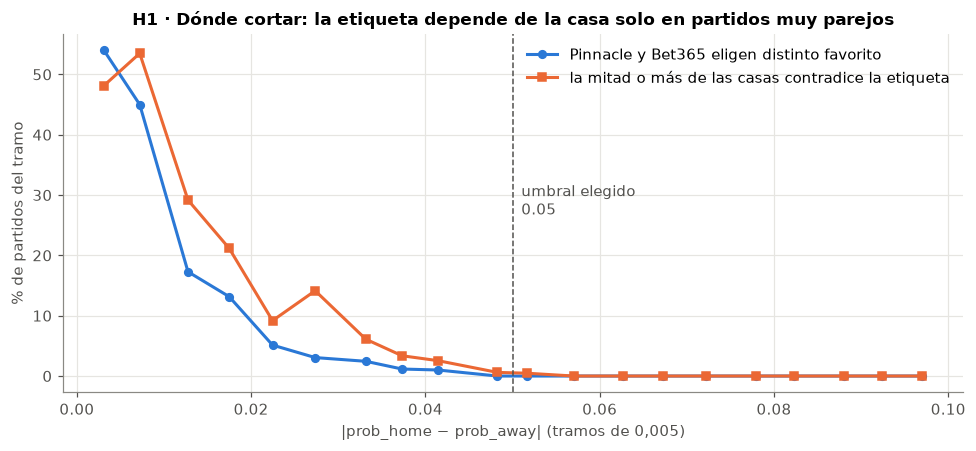

,umbral,filas_quedan,filas_eliminadas,pct_eliminado,target_true,target_false,tasa_victoria_underdog_pct,tasa_victoria_favorito_pct,dif_media_prob,pct_favorito_cambia_ps_b365,pct_mercado_contradice,eliminadas_pct_favorito_cambia_ps_b365
0,0.000,19559,103,0.52,4192,15367,21.43,53.39,0.3068,1.14,1.32,67.74
1,0.020,18983,679,3.45,4005,14978,21.10,53.82,0.3158,0.11,0.33,33.16
2,0.030,18694,968,4.92,3903,14791,20.88,54.11,0.3203,0.04,0.14,24.07
3,0.050,17959,1703,8.66,3654,14305,20.35,54.70,0.3317,0.00,0.01,15.02
4,0.075,16967,2695,13.71,3365,13602,19.83,55.61,0.3475,0.00,0.01,9.85
5,0.100,15977,3685,18.74,3042,12935,19.04,56.51,0.3636,0.00,0.01,7.18


In [6]:
bands = stability_by_gap_band(candidates, width=0.005, upper=0.10)
bands = bands[bands["gap_medio"] <= 0.10]
fig, ax = plt.subplots()
ax.plot(bands["gap_medio"], bands["pct_favorito_cambia_ps_b365"], color=BLUE, marker="o", markersize=5, linewidth=2, label="Pinnacle y Bet365 eligen distinto favorito")
ax.plot(bands["gap_medio"], bands["pct_mercado_contradice"], color=ORANGE, marker="s", markersize=5, linewidth=2, label="la mitad o más de las casas contradice la etiqueta")
ax.axvline(UNDERDOG_MIN_PROB_GAP, color=INK, linestyle="--", linewidth=1)
ax.text(UNDERDOG_MIN_PROB_GAP + 0.001, 32, f"umbral elegido\n{UNDERDOG_MIN_PROB_GAP}", color=INK, va="top")
ax.set_xlabel("|prob_home − prob_away| (tramos de 0,005)")
ax.set_ylabel("% de partidos del tramo")
ax.set_title("H1 · Dónde cortar: la etiqueta depende de la casa solo en partidos muy parejos")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()
threshold_sensitivity(pd.read_parquet(INTERMEDIATE_DIR / "matches_with_target.parquet"), UNDERDOG_GAP_CANDIDATES)

## H2 · Con mejor XI titular, el underdog gana más
*Pregunta: responder (dominio). Plantilla: comparación de una numérica entre dos grupos.*

**1. La afirmación**
`nofav_xi_overall_mean_gap` (overall medio del XI del underdog menos el del XI del favorito) es mayor en los partidos que ganó
el underdog (`gano_no_favorito = True`) que en los demás.

**2. Qué espero ver** **[BORRADOR — reescribir con sus palabras antes de entregar]**
En la Entrega 1 vimos que, con el XI del underdog mejor, su tasa de victoria subía de 19,3% a 28,6%. Esperamos una separación
grande, en verde: que los jugadores que salen a la cancha expliquen buena parte de las sorpresas.

**3. Cómo la mido**
Plantilla de comparación → **separación estandarizada** de `nofav_xi_overall_mean_gap` entre "ganó el underdog" y "no ganó".
Gráfico: distribución del gap en cada grupo y, al lado, cómo se mueve el gap con la probabilidad que le da el mercado al underdog.

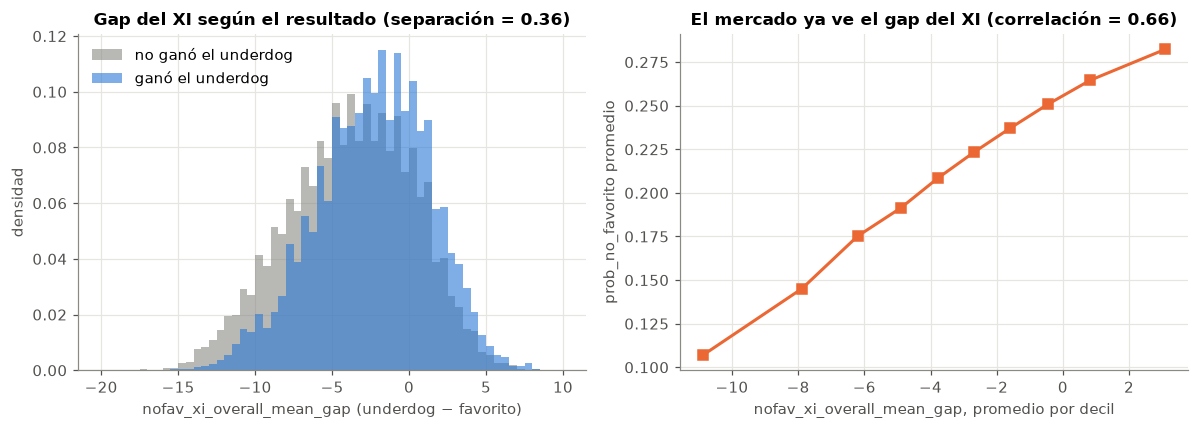

Separación estandarizada: 0,358 → 🟡 amarillo
Correlación del gap del XI con prob_no_favorito: 0.66
Separación de prob_no_favorito entre ganó y no ganó: 0.50


In [7]:
y = df[TARGET_COLUMN]
d_h2 = separacion_estandarizada(df["nofav_xi_overall_mean_gap"], y)
r_market = correlacion(df["nofav_xi_overall_mean_gap"], df["prob_no_favorito"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
bins = np.linspace(-20, 10, 61)
ax1.hist(df.loc[~y, "nofav_xi_overall_mean_gap"], bins=bins, density=True, color=GRAY, alpha=0.6, label="no ganó el underdog")
ax1.hist(df.loc[y, "nofav_xi_overall_mean_gap"], bins=bins, density=True, color=BLUE, alpha=0.6, label="ganó el underdog")
ax1.set_title(f"Gap del XI según el resultado (separación = {d_h2:.2f})")
ax1.set_xlabel("nofav_xi_overall_mean_gap (underdog − favorito)")
ax1.set_ylabel("densidad")
ax1.legend(loc="upper left")

deciles = pd.qcut(df["nofav_xi_overall_mean_gap"], 10)
by_decile = df.groupby(deciles, observed=True).agg(gap=("nofav_xi_overall_mean_gap", "mean"), prob=("prob_no_favorito", "mean"))
ax2.plot(by_decile["gap"], by_decile["prob"], color=ORANGE, marker="s", markersize=6, linewidth=2)
ax2.set_title(f"El mercado ya ve el gap del XI (correlación = {r_market:.2f})")
ax2.set_xlabel("nofav_xi_overall_mean_gap, promedio por decil")
ax2.set_ylabel("prob_no_favorito promedio")
plt.tight_layout()
plt.show()
print("Separación estandarizada:", semaforo("separacion_estandarizada", d_h2))
print(f"Correlación del gap del XI con prob_no_favorito: {r_market:.2f}")
print(f"Separación de prob_no_favorito entre ganó y no ganó: {separacion_estandarizada(df['prob_no_favorito'], y):.2f}")

**4. Qué encontré**
Separación estandarizada = **0,36 → 🟡 amarillo**. El efecto existe pero es moderado. El segundo gráfico muestra algo más:
el gap del XI sube junto con `prob_no_favorito` (correlación 0,66). Los underdogs con mejor XI son justamente a los que el
mercado ya les da más chances.

**5. Qué movimiento hice**
**Controlar una tercera variable: `prob_no_favorito`.** El gráfico muestra que la cuota empuja a las dos cosas a la vez: se mueve
con el gap del XI (0,66) y también separa ganadores de perdedores (0,50). Así que recalculé la separación del gap del XI
**dentro de cada quintil** de `prob_no_favorito`, comparando partidos a los que el mercado les daba la misma chance.

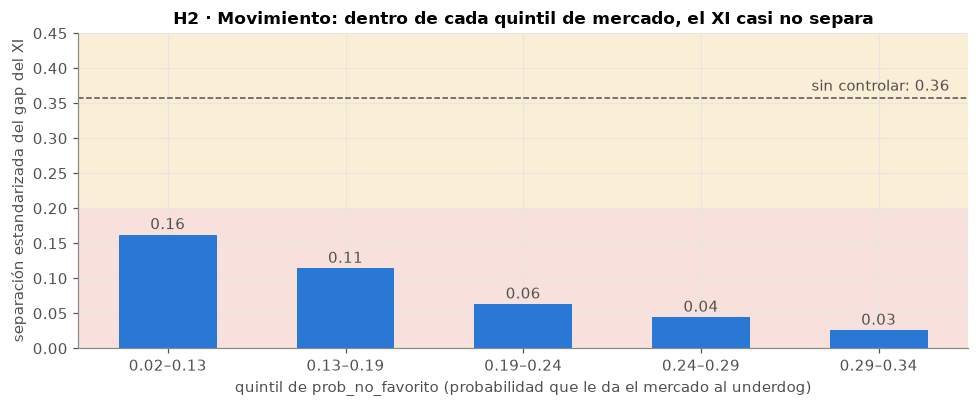

Separación por quintil: {'0.02–0.13': 0.162, '0.13–0.19': 0.114, '0.19–0.24': 0.063, '0.24–0.29': 0.044, '0.29–0.34': 0.026}
Zona en cada quintil: ['rojo', 'rojo', 'rojo', 'rojo', 'rojo']


In [8]:
quintil = pd.qcut(df["prob_no_favorito"], 5)
controlled = pd.Series({
    f"{iv.left:.2f}–{iv.right:.2f}": separacion_estandarizada(g["nofav_xi_overall_mean_gap"], g[TARGET_COLUMN])
    for iv, g in df.groupby(quintil, observed=True)
})
fig, ax = plt.subplots(figsize=(9, 3.8))
for lo, hi, z in ((0, 0.2, "rojo"), (0.2, 0.8, "amarillo")):
    ax.axhspan(lo, hi, color=ZONE_COLOR[z], zorder=0)
ax.axhline(d_h2, color=INK, linestyle="--", linewidth=1)
ax.text(len(controlled) - 0.6, d_h2 + 0.01, f"sin controlar: {d_h2:.2f}", color=INK, ha="right")
ax.bar(controlled.index, controlled.values, color=BLUE, width=0.55, zorder=2)
for i, v in enumerate(controlled.values):
    ax.text(i, v + 0.008, f"{v:.2f}", ha="center", color=INK)
ax.set_ylim(0, 0.45)
ax.set_title("H2 · Movimiento: dentro de cada quintil de mercado, el XI casi no separa")
ax.set_xlabel("quintil de prob_no_favorito (probabilidad que le da el mercado al underdog)")
ax.set_ylabel("separación estandarizada del gap del XI")
plt.tight_layout()
plt.show()
print("Separación por quintil:", {k: round(v, 3) for k, v in controlled.items()})
print("Zona en cada quintil:", [zona("separacion_estandarizada", v) for v in controlled.values])

Controlando por el mercado, la separación cae a **0,16; 0,11; 0,06; 0,04 y 0,03 → 🔴 rojo en los cinco quintiles.**

**6. Qué hago con eso**
**Refutada.** Una vez que se conoce la cuota, el XI casi no distingue a los underdogs que ganan de los que no: el mercado ya
descuenta la alineación. `nofav_xi_overall_mean_gap` **entra** (contra el objetivo solo está en amarillo), pero siempre junto
con `prob_no_favorito`. En la Entrega 3 el modelo se compara **contra el modelo solo-mercado**: si no lo supera, la conclusión
del proyecto es que la alineación no agrega información a las cuotas. La comparación "19,3% → 28,6%" de la Entrega 1 era, en su
mayor parte, información que ya estaba en las cuotas.

## H3 · Los subatributos del arquero repiten a `gk_overall`
*Pregunta: decidir columnas del modelo. Plantilla: asociación entre dos numéricas.*

**1. La afirmación**
Como diferencia underdog − favorito, `gk_reflexes`, `gk_diving` y `gk_handling` tienen una correlación **mayor a 0,6** con
`gk_overall`: miden lo mismo, y no hace falta tenerlos por separado.

**2. Qué espero ver** **[BORRADOR — reescribir con sus palabras antes de entregar]**
Esperamos correlaciones altas, porque en los juegos FIFA el overall de un arquero sale casi solo de sus atributos de arquero.
La duda es `gk_handling`, que podría medir algo distinto de los reflejos.

**3. Cómo la mido**
Plantilla de asociación → **correlación** (Pearson) entre el gap de cada subatributo y el gap de `gk_overall`, más la **brecha
Spearman − Pearson** para ver si la relación es recta. Gráfico: nube de puntos de cada par. Los subatributos no están en Silver,
así que se leen de `lineup_features.parquet` y se orientan igual que los gaps.

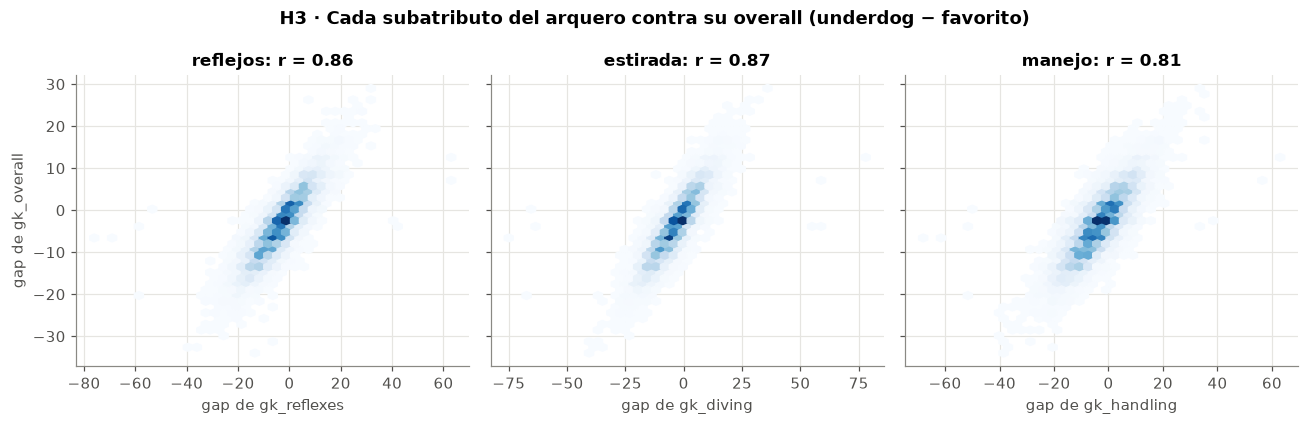

gk_reflexes  correlación 0,855 → 🟢 verde   brecha Spearman−Pearson 0,001 → 🔴 rojo
gk_diving    correlación 0,865 → 🟢 verde   brecha Spearman−Pearson 0,004 → 🔴 rojo
gk_handling  correlación 0,807 → 🟢 verde   brecha Spearman−Pearson 0,012 → 🔴 rojo


In [9]:
lineups = pd.read_parquet(INTERMEDIATE_DIR / "lineup_features.parquet").rename(columns={"match_api_id": "match_id"})
lineups = df[["match_id", "equipo_favorito"]].merge(lineups, on="match_id", validate="one_to_one")
underdog_local = lineups["equipo_favorito"] == "visitante"


def underdog_minus_favourite(metric):
    home, away = lineups[f"home_{metric}"], lineups[f"away_{metric}"]
    return pd.Series(np.where(underdog_local, home - away, away - home), index=lineups.index)


gk = underdog_minus_favourite("gk_overall")
fig, axes = plt.subplots(1, 3, figsize=(12, 3.9), sharey=True)
h3 = {}
for ax, metric, label in zip(axes, ["gk_reflexes", "gk_diving", "gk_handling"], ["reflejos", "estirada", "manejo"]):
    sub = underdog_minus_favourite(metric)
    ok = gk.notna() & sub.notna()
    r, gap = correlacion(sub[ok], gk[ok]), brecha_spearman_pearson(sub[ok], gk[ok])
    h3[metric] = (r, gap)
    ax.hexbin(sub[ok], gk[ok], gridsize=40, cmap="Blues", mincnt=1)
    ax.set_title(f"{label}: r = {r:.2f}")
    ax.set_xlabel(f"gap de {metric}")
axes[0].set_ylabel("gap de gk_overall")
fig.suptitle("H3 · Cada subatributo del arquero contra su overall (underdog − favorito)", fontweight="bold")
plt.tight_layout()
plt.show()
for metric, (r, gap) in h3.items():
    print(f"{metric:12s} correlación {semaforo('correlacion', r)}   brecha Spearman−Pearson {semaforo('brecha_spearman_pearson', gap)}")

**4. Qué encontré**
Correlación **0,86** con reflejos, **0,87** con estirada y **0,81** con manejo → **🟢 verde los tres**. La brecha Spearman − Pearson va de
0,001 a 0,012 (rojo): la relación es recta, no hace falta cambiar la escala. Ni siquiera el manejo mide algo distinto.

**5. Qué movimiento hice**
Ninguno: dio verde.

**6. Qué hago con eso**
**Salen** las 6 columnas `home_/away_gk_reflexes`, `gk_diving` y `gk_handling`: repiten la información de `gk_overall`. El arquero
queda representado por `nofav_gk_overall_gap`. Pero en la tabla de candidatas esa columna también queda en rojo contra el objetivo
(0,16), así que tampoco va al modelo.

## H4 · La tasa de victoria del underdog depende de la liga
*Pregunta: decidir una columna del modelo (`liga`). Plantilla: comparación de una numérica entre muchos grupos.*

**1. La afirmación**
La proporción de partidos que gana el underdog cambia según la liga: el **η²** de `gano_no_favorito` entre las 9 ligas es de al
menos 0,05.

**2. Qué espero ver** **[BORRADOR — reescribir con sus palabras antes de entregar]**
Esperamos diferencias: las ligas con pocos equipos dominantes (Escocia, Portugal) deberían tener menos sorpresas que las más
parejas (Alemania, Inglaterra). No sabemos si alcanza para salir del rojo.

**3. Cómo la mido**
Plantilla de comparación entre muchos grupos → **η²** (razón de correlación) de `gano_no_favorito` según `liga`. Gráfico: tasa de
victoria del underdog por liga, con su intervalo del 95% y el promedio general.

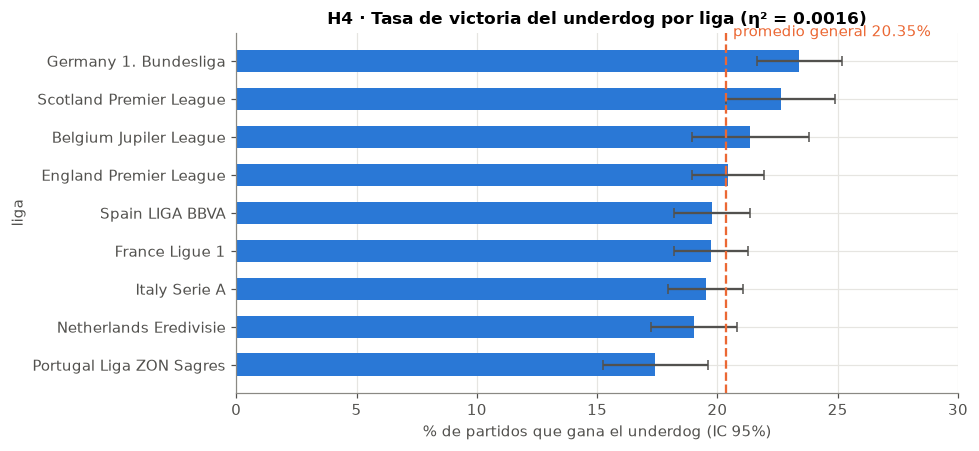

η²: 0,0016 → 🔴 rojo
liga
Portugal Liga ZON Sagres    17.4
Netherlands Eredivisie      19.0
Italy Serie A               19.5
France Ligue 1              19.7
Spain LIGA BBVA             19.8
England Premier League      20.4
Belgium Jupiler League      21.4
Scotland Premier League     22.6
Germany 1. Bundesliga       23.4


In [10]:
eta_h4 = eta_cuadrado(df[TARGET_COLUMN], df["liga"])
by_league = df.groupby("liga")[TARGET_COLUMN].agg(["mean", "size"]).sort_values("mean")
err = 1.96 * np.sqrt(by_league["mean"] * (1 - by_league["mean"]) / by_league["size"]) * 100
overall = df[TARGET_COLUMN].mean() * 100

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(by_league.index, by_league["mean"] * 100, xerr=err, color=BLUE, height=0.6, error_kw={"ecolor": INK, "capsize": 3})
ax.axvline(overall, color=ORANGE, linestyle="--", linewidth=1.5)
ax.text(overall + 0.3, len(by_league) - 0.35, f"promedio general {overall:.2f}%", color=ORANGE)
ax.set_xlim(0, 30)
ax.set_title(f"H4 · Tasa de victoria del underdog por liga (η² = {eta_h4:.4f})")
ax.set_xlabel("% de partidos que gana el underdog (IC 95%)")
ax.set_ylabel("liga")
plt.tight_layout()
plt.show()
print("η²:", semaforo("eta2", eta_h4))
print((by_league["mean"] * 100).round(1).to_string())

**4. Qué encontré**
η² = **0,0016 → 🔴 rojo**. Hay diferencias: el underdog gana el 17,4% en Portugal y el 23,4% en Alemania, contra un 20,35% general.
Pero la liga explica apenas el 0,16% de la variación del objetivo, y Escocia (22,6%), que esperábamos con menos sorpresas, está entre
las que más tienen.

**5. Qué movimiento hice**
Ninguno: dio rojo.

**6. Qué hago con eso**
**`liga` sale del modelo.** La diferencia entre ligas no alcanza para cambiar una decisión. La columna queda en Silver para
analizar resultados por liga y para cortar en validación, pero no como feature.

---
# Parte 3 — Tabla de columnas candidatas

Una fila por cada columna que pensamos darle al modelo, más las que descartamos por fuga. La **zona** es la del semáforo de cada
columna contra el objetivo: separación estandarizada si la columna es numérica, η² si es categórica. **Regla: amarillo o verde
entra; rojo sale.** La excepción son los descartes por fuga, que salen aunque separen perfecto.

In [11]:
zones = zonas_de_candidatas(df, catalog.CANDIDATE_COLUMNS).set_index("columna")
table = pd.DataFrame({
    "qué mide": [spec[c].description for c in zones.index],
    "medida contra el objetivo": zones["medida"],
    "valor": zones["valor"],
    "zona": zones["zona"],
    "decisión": [spec[c].decision.capitalize() for c in zones.index],
    "¿existiría al predecir?": "Sí",
}, index=zones.index)
# La zona y la decisión del catálogo del pipeline tienen que coincidir con las que acabamos de medir.
assert all(spec[c].zone == zones.loc[c, "zona"] for c in zones.index)

audit = {c.name: c for c in catalog.AUDIT_COLUMNS}
leaks = pd.DataFrame({
    "qué mide": [audit[c].description for c in ["goles_local", "goles_visitante", "resultado_ft", "resultado_no_favorito"]],
    "medida contra el objetivo": "—", "valor": np.nan, "zona": "—", "decisión": "Sale",
    "¿existiría al predecir?": "No — se completa al terminar el partido",
}, index=["goles_local", "goles_visitante", "resultado_ft", "resultado_no_favorito"])
candidates_table = pd.concat([table, leaks]).rename_axis("columna")
print(f"Entran {int((table['decisión'] == 'Entra').sum())} de {len(table)} candidatas; salen {int((table['decisión'] == 'Sale').sum())} por semáforo y 4 por fuga.")
with pd.option_context("display.max_rows", 60, "display.max_colwidth", 70):
    display(candidates_table)

Entran 12 de 23 candidatas; salen 11 por semáforo y 4 por fuga.


,qué mide,medida contra el objetivo,valor,zona,decisión,¿existiría al predecir?
columna,,,,,,
jornada,Número de fecha dentro de la temporada.,separación estandarizada,0.0122,rojo,Sale,Sí
liga,Liga del partido.,η²,0.0016,rojo,Sale,Sí
prob_draw,Probabilidad implícita normalizada de empate.,separación estandarizada,0.4292,amarillo,Entra,Sí
equipo_favorito,Qué equipo es el favorito: 'local' o 'visitante'.,η²,0.0016,rojo,Sale,Sí
prob_no_favorito,Probabilidad implícita de victoria del underdog.,separación estandarizada,0.4965,amarillo,Entra,Sí
nofav_xi_overall_mean_gap,Ventaja del underdog en calidad media del once titular. Positivo =...,separación estandarizada,0.3579,amarillo,Entra,Sí
nofav_top3_overall_gap,Ventaja del underdog en calidad de las 3 figuras del once. Positiv...,separación estandarizada,0.3286,amarillo,Entra,Sí
nofav_best_overall_gap,Ventaja del underdog en calidad del mejor jugador en cancha. Posit...,separación estandarizada,0.3073,amarillo,Entra,Sí
nofav_worst_overall_gap,Ventaja del underdog en el eslabón más débil del once. Positivo = ...,separación estandarizada,0.2250,amarillo,Entra,Sí


**Decisión.** El modelo de la Entrega 3 recibe **12 columnas**: `prob_no_favorito`, `prob_draw` y los gaps del XI (promedio, top 3,
mejor, peor, defensa, mediocampo, ataque, definición, reacción y marca). Salen por semáforo:
- el arquero, la velocidad, la fuerza, la edad, la altura y la dispersión del XI;
- las dos formaciones, `equipo_favorito`, `jornada` y `liga`.

Todas siguen en Silver para análisis. La tabla con las 82 columnas de la Entrega 1 y el destino de cada una está en
`docs/column_candidates.md`.

---
# Parte 4 — Control final de fuga

In [12]:
leakage = catalog.leakage_audit_frame(list(df.columns))
X, y_model = catalog.split_features_target(df)
aucs = pd.Series({c: single_feature_auc(df[c], y_model) for c in catalog.CANDIDATE_COLUMNS if pd.api.types.is_numeric_dtype(df[c])}).sort_values(ascending=False)

assert not leakage["leakage"].any(), "hay columnas con fuga en Silver"
assert TARGET_COLUMN not in X.columns and not set(X.columns) & set(catalog.LEAKAGE_COLUMNS)
assert all(spec[c].available == catalog.PRE for c in X.columns)
print(f"X: {X.shape[1]} features, todas pre-partido | y = {TARGET_COLUMN} ({y_model.mean():.2%} positivos)")
print(f"Columnas con fuga en Silver: {int(leakage['leakage'].sum())}")
print(f"Mejor AUC de una sola candidata: {aucs.index[0]} = {aucs.iloc[0]:.3f} (una columna con el resultado adentro daría ~1)")
print("Quality checks del pipeline:", "todos OK" if run_quality_checks(df)["passed"] else "FALLAN")
leakage

X: 12 features, todas pre-partido | y = gano_no_favorito (20.35% positivos)
Columnas con fuga en Silver: 0
Mejor AUC de una sola candidata: prob_no_favorito = 0.638 (una columna con el resultado adentro daría ~1)


Quality checks del pipeline: todos OK


,columna,origen,momento_disponible,candidata,feature,target,leakage,decision
0,match_id,fuente,pre-partido,False,False,False,False,IDENTIFICADOR
1,fecha,fuente,pre-partido,False,False,False,False,AUXILIAR
2,temporada,fuente,pre-partido,False,False,False,False,AUXILIAR
3,jornada,fuente,pre-partido,True,False,False,False,SALE
4,liga,fuente,pre-partido,True,False,False,False,SALE
5,odds_source,calculada,pre-partido,False,False,False,False,AUXILIAR
6,prob_home,calculada,pre-partido,False,False,False,False,AUXILIAR
7,prob_draw,calculada,pre-partido,True,True,False,False,ENTRA
8,prob_away,calculada,pre-partido,False,False,False,False,AUXILIAR
9,equipo_favorito,calculada,pre-partido,True,False,False,False,SALE


**Qué columna descartamos por fuga y cuándo se completa.** `goles_local` y `goles_visitante` se completan cuando termina el partido,
y lo mismo `resultado_ft` y `resultado_no_favorito`, que además contiene el objetivo copiado ("gano" ⇔ True). Se usan una sola vez,
para construir el objetivo, y después viven en `include/data/audit/`, no en Silver. Las columnas de eventos del partido (`goal`,
`card`, `possession`…) ni siquiera se extraen de la base. La mejor candidata sola llega a AUC 0,64: es información de mercado, no
del resultado.

---
# Cierre

- **Objetivo**: `gano_no_favorito`, 20,35% True. Ninguna clase se come todo, pero se evalúa con AUC y log-loss.
- **Nulos**: 6 columnas con faltantes de verdad (4 partidos con coordenadas mal cargadas en la fuente). Ningún nulo estructural:
  los 103 targets nulos de la Entrega 1 eran partidos sin underdog, y salieron.
- **Qué hipótesis nos salió mal**: la H2. Esperábamos verde, dio amarillo, y al controlar por el mercado cayó a rojo: la
  alineación casi no agrega información a las cuotas. La H4 también dio rojo: la liga no importa.
- **Al modelo** van 12 columnas; salen 11 candidatas por semáforo y 4 por fuga.
- **Qué quedó inconcluso**:
  - Si los gaps de jugadores, **juntos**, le ganan al modelo solo-mercado. Es la pregunta de la Entrega 3.
  - Qué hacer con la redundancia entre gaps del XI (correlaciones de 0,86 a 0,96).
  - Cómo cambiaría todo con cuotas de cierre, que en esta fuente no hay.